# MFIS[1-4] $\rightarrow$ MFIS[5]

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler
from src.train import LSTMRegressionXV
from src.core.data_transforms import Transform


import torch

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
K_FOLDS = 5
N_VISITS = 4

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [34]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam

config = ModelConfig(
    name="lstm_regression",
    model_type="LSTM",
    input_size=25,
    hidden_size=128,
    num_layers=1,
    output_size=1,
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
)

config.notes = "None"

In [5]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
]

In [6]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
    #static_features=static_features
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [8]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [9]:
# remove missing labels
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
fatigue_value = dmo_labels[patient_indexs]

In [10]:
fatigue_value.shape

torch.Size([428, 4, 1])

In [13]:
dmo_data.shape

torch.Size([428, 4, 24])

In [12]:
dmo_data = dmo_data.mean(axis=2)

In [14]:
# Min max normalise all fatigue values
physical_subset_max = 36
fatigue_value = fatigue_value / physical_subset_max

In [15]:
fatigue_value[0]

tensor([[0.1944],
        [0.4167],
        [0.6389],
        [0.3611]])

In [26]:
current_features = dmo_data[:, 1:, :]
prev_labels = dmo_labels[:, :-1, :]
X_tensor = torch.cat((current_features, prev_labels), dim=2)
y_tensor = fatigue_value[:, -1, :]

In [27]:
X_tensor.shape

torch.Size([428, 3, 25])

In [28]:
X_tensor[0]

tensor([[3.1857e+02, 5.4857e+01, 4.4901e+03, 7.1000e+00, 1.8171e+01, 1.2157e+02,
         8.8000e+01, 1.2729e+00, 1.2143e+01, 2.0571e+01, 6.2429e-01, 8.7571e+01,
         9.0571e+01, 8.1571e-01, 1.0000e+01, 8.5429e-01, 1.1343e+02, 8.7571e+01,
         1.2343e+00, 1.1529e+00, 9.3714e+01, 2.9286e+01, 2.5714e+01, 2.4286e+00,
         7.0000e+00],
        [2.6443e+02, 4.2857e+01, 3.3640e+03, 7.1000e+00, 1.6786e+01, 1.1486e+02,
         8.8143e+01, 1.3129e+00, 1.2143e+01, 1.9714e+01, 6.0286e-01, 8.5143e+01,
         7.6429e+01, 7.2571e-01, 7.0000e+00, 6.9857e-01, 9.5000e+01, 8.6714e+01,
         1.3057e+00, 8.7000e-01, 9.1714e+01, 1.9143e+01, 1.8714e+01, 1.1429e+00,
         1.5000e+01],
        [2.3229e+02, 3.4000e+01, 2.8866e+03, 6.7571e+00, 1.5857e+01, 8.2143e+01,
         8.8429e+01, 1.2271e+00, 1.2571e+01, 2.1857e+01, 5.9429e-01, 8.2143e+01,
         5.9571e+01, 8.5857e-01, 4.2857e+00, 8.7805e-01, 1.0954e+02, 9.1640e+01,
         1.1320e+00, 1.1349e+00, 9.8252e+01, 3.1094e+01, 2.5784e+

In [29]:
y_tensor.shape

torch.Size([428, 1])

In [30]:
y_tensor[0]

tensor([0.3611])

In [35]:
xv_trainer = LSTMRegressionXV(X_tensor, y_tensor, config, device, k=K_FOLDS)
prediction, actual = xv_trainer.train_cross_validation(
    pred_transform=lambda x: x[:, -1, :]
)


Testing loss: 0.02579923750211795
Testing loss: 0.026208211667835712
Testing loss: 0.026927489632119734
Testing loss: 0.023957383663703997
Testing loss: 0.030452010532220204


In [36]:
prediction[0].shape

torch.Size([86])

In [37]:
prediction = torch.concatenate(prediction).flatten()
prediction = (prediction * physical_subset_max).flatten()
prediction.shape

torch.Size([428])

In [38]:
actual = torch.concatenate(actual).flatten()
actual = (actual * physical_subset_max).flatten()
actual.shape

torch.Size([428])

In [39]:
print(xv_trainer.R2_values)

[0.5430760383605957, 0.589893102645874, 0.5442383289337158, 0.486322820186615, 0.5666306614875793]


All metrics: {'accuracy': 0.009345794392523364, 'Mean Squared Error': 31.604658126831055, 'Mean Absolute Error': 4.4303412437438965, 'R^2': 0.5534368753433228}


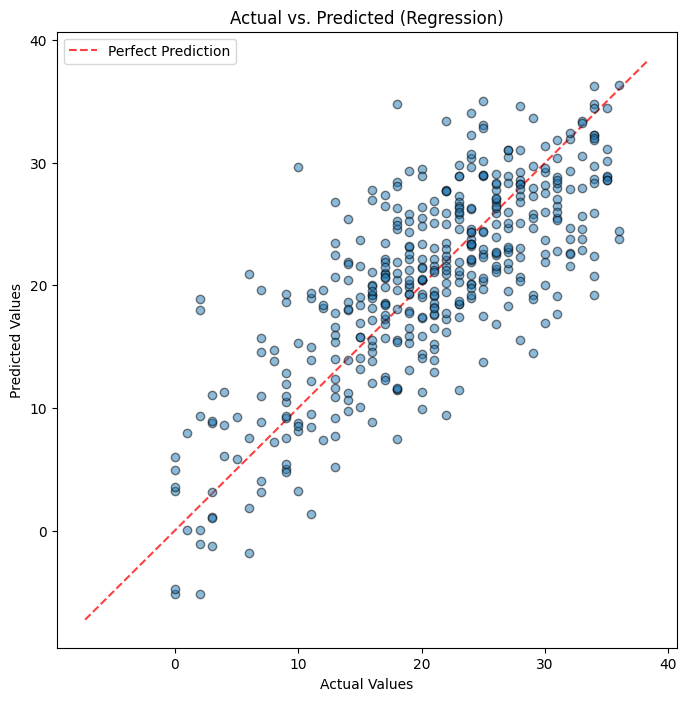

In [40]:
from src.evaluation import Evaluation

evaluation = Evaluation(prediction, actual)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()
